In [27]:

from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
import math

plt.rcParams["figure.figsize"] = 10,5
plt.rcParams["font.size"] = 16

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})


1000


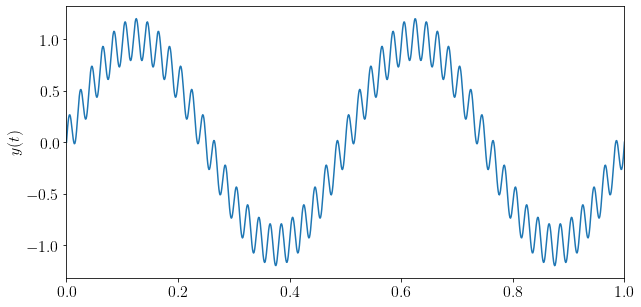

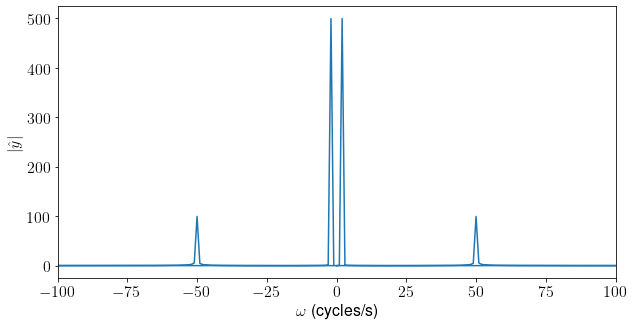

In [108]:
# Generate a signal
samplingFreq = 1000;  # sampled at 1 kHz = 1000 samples / second
tlims = [0,1]
signalFreq = [2,50]; # Cycles / second
signalMag = [1,0.2]; 
t = np.linspace(tlims[0],tlims[1],(tlims[1]-tlims[0])*samplingFreq)
y = signalMag[0]*np.sin(2*math.pi*signalFreq[0]*t) + signalMag[1]*np.sin(2*math.pi*signalFreq[1]*t)

print(len(t))
# Plot the signal
plt.figure()
plt.plot(t,y);
plt.ylabel("$y(t)$")
plt.xlim([min(t),max(t)]);

# Generate Fourier transform
yhat = np.fft.fft(y)
fcycles = np.fft.fftfreq(len(t),d=1.0/samplingFreq)

plt.figure()
plt.plot(fcycles,np.absolute(yhat));
plt.xlim([-100,100]);
plt.xlabel("$\omega$ (cycles/s)");
plt.ylabel("$|\hat{y}|$");

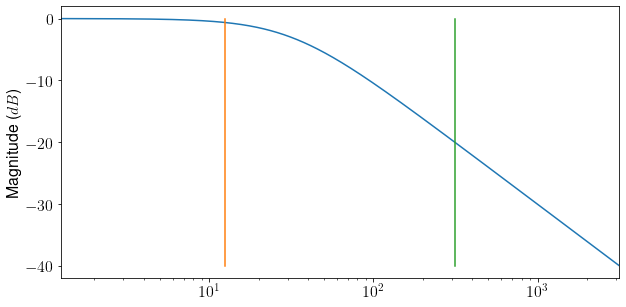

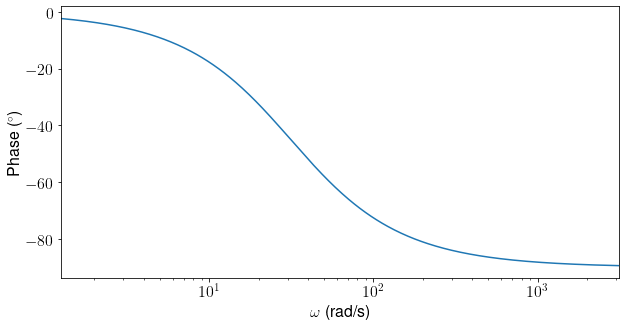

In [112]:
# Low pass filter

w0 = 2*np.pi*5; #pole frequency (rad/s)
num = w0
den = [1,w0]

w = np.logspace( np.log10(min(signalFreq)*2*np.pi/10), np.log10(max(signalFreq)*2*np.pi*10), 500 )
lowPass = signal.TransferFunction(num,den)
w, mag, phase = signal.bode(lowPass,w)

# Magnitude plot
plt.figure()
plt.semilogx(w, mag)

for sf in signalFreq:
    plt.semilogx([sf*2*np.pi,sf*2*np.pi],[min(mag),max(mag)])
    
plt.ylabel("Magnitude ($dB$)")
plt.xlim([min(w),max(w)])

# Phase plot
plt.figure()
plt.semilogx(w, phase)  # Bode phase plot
plt.ylabel("Phase ($^\circ$)")
plt.xlabel("$\omega$ (rad/s)")
plt.xlim([min(w),max(w)])
plt.show()


In [97]:
# Compute the discrete low pass with delta_t = 1/samplingFrequency
dt = 1.0/samplingFreq;
discreteLowPass = lowPass.to_discrete(dt,method='gbt',alpha=0.5)
print(discreteLowPass)

TransferFunctionDiscrete(
array([0.01546504, 0.01546504]),
array([ 1.        , -0.96906992]),
dt: 0.001
)


In wolfram alpha you can derive this algebraically:

<code>w0/((2/T)*(1-z^-1)/(1+z^-1) + w0) where w0 = 10, T = 0.001</code>

For a discrete system 
$$y[n] = a_1 y[n-1] + a_2 y[n-2] + ... + b_0 x[n] + b_1 x[n-1] + ...$$

The coefficients can be taken directly from the transfer function as
$$H(z) = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2} + \ldots}{1 - a_1 z^{-1} - a_2 z^{-2} + \ldots}$$

The transfer function defined with

<code>num = [b_0, b_1, b_2]</code>

<code>den = [1, a_1, a_2]</code>

is 
$$H(z) = \frac{b_0 z^2 + b_1 z + b_2}{z^2 + a_1 z + a_2}$$
which is equivalent to
$$H(z) = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{1 + a_1 z^{-1} + a_2 z^{-2}}$$

So you can take the coefficients in the same order that they are defined in the numerator and denominator of the transfer function object. The only difference is that the **coefficients in the denominator need a negative sign**.


[-1.          0.96906992]
[0.01546504 0.01546504]
1000


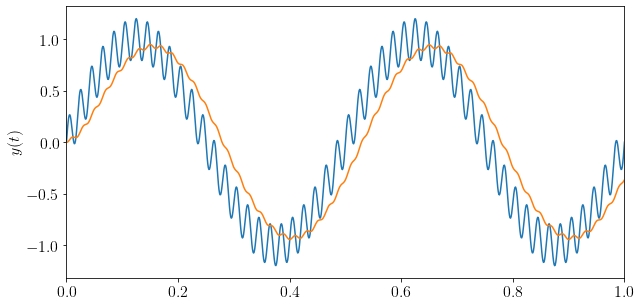

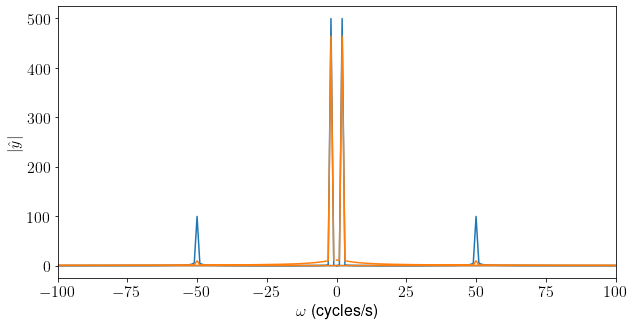

In [94]:
# Construct and apply the discrete filter

# The coefficients from the filters
a = -discreteLowPass.den;
b = discreteLowPass.num;
print(a)
print(b)


# Filter the signal
yfilt = np.zeros(len(y));
for i in range(3,len(y)):
    yfilt[i] = a[1]*yfilt[i-1] + b[0]*y[i] + b[1]*y[i-1];
    
# View the result
print(len(t))
# Plot the signal
plt.figure()
plt.plot(t,y);
plt.plot(t,yfilt);
plt.ylabel("$y(t)$")
plt.xlim([min(t),max(t)]);

# Generate Fourier transform
yfilthat = np.fft.fft(yfilt)
fcycles = np.fft.fftfreq(len(t),d=1.0/samplingFreq)

plt.figure()
plt.plot(fcycles,np.absolute(yhat));
plt.plot(fcycles,np.absolute(yfilthat));
plt.xlim([-100,100]);
plt.xlabel("$\omega$ (cycles/s)");
plt.ylabel("$|\hat{y}|$");

